# Task 1
## Binary Classification using KNN from scratch




In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, precision_score, recall_score, accuracy_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


In [5]:
df = pd.read_csv("data.csv")

# Map diagnosis: M=1 (Malignant), B=0 (Benign)
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

# Drop 'id' and unnamed columns
columns_to_drop = ['id']
unnamed_cols = [col for col in df.columns if 'Unnamed' in str(col)]
columns_to_drop.extend(unnamed_cols)
columns_to_drop = [col for col in columns_to_drop if col in df.columns]
df = df.drop(columns=columns_to_drop)

print(f"Dropped columns: {columns_to_drop}")
print(f"DataFrame shape after dropping columns: {df.shape}")
print(f"DataFrame columns: {df.columns.tolist()}")
print(f"Missing values: {df.isnull().sum().sum()}")

# Separate features & target
y = df['diagnosis'].values
X_df = df.drop(columns=['diagnosis'])

print(f"\nFeature matrix shape: {X_df.shape}")
print(f"Missing values in features: {X_df.isnull().sum().sum()}")

X = X_df.values

nan_count = np.isnan(X).sum()
inf_count = np.isinf(X).sum()
print(f"NaN values in X: {nan_count}")
print(f"Infinite values in X: {inf_count}")

if nan_count > 0 or inf_count > 0:
    finite_mask = np.isfinite(X).all(axis=1) & np.isfinite(y)
    X, y = X[finite_mask], y[finite_mask]
    print(f"Rows removed due to NaN/Inf: {len(finite_mask) - finite_mask.sum()}")

print(f"Final dataset shape: {X.shape}")
print(f"Class distribution: {Counter(y)}")


Dropped columns: ['id', 'Unnamed: 32']
DataFrame shape after dropping columns: (569, 31)
DataFrame columns: ['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']
Missing values: 0

Feature matrix shape: (569, 30)
Missing values in features: 0
NaN values in X: 0
Infinite values in X: 0
Final dataset shape: (569, 30)
Class distribution: Counter({np.int64(0): 357, np.int64(1): 212})


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


## 2. Distance Metrics


In [7]:
def euclidean_distance(x1, x2):
    return np.sqrt(np.sum((x1 - x2) ** 2))

def manhattan_distance(x1, x2):
    return np.sum(np.abs(x1 - x2))

def minkowski_distance(x1, x2, p=3):
    return np.sum(np.abs(x1 - x2) ** p) ** (1 / p)

def cosine_similarity(x1, x2):
    num = np.dot(x1, x2)
    den = np.linalg.norm(x1) * np.linalg.norm(x2)
    return 0 if den == 0 else 1 - (num / den)

def hamming_distance(x1, x2):
    return np.mean(x1 != x2)

distance_functions = {
    "Euclidean": euclidean_distance,
    "Manhattan": manhattan_distance,
    "Minkowski": lambda x1, x2: minkowski_distance(x1, x2, p=3),
    "Cosine": cosine_similarity,
    "Hamming": hamming_distance
}


## 3. KNN Classifier from Scratch


In [8]:
class KNNClassifier:
    def __init__(self, k=3, distance_func=euclidean_distance):
        self.k = k
        self.distance_func = distance_func

    def fit(self, X_train, y_train):
        self.X_train, self.y_train = X_train, y_train

    def predict_one(self, x):
        distances = [self.distance_func(x, x_train) for x_train in self.X_train]
        k_idx = np.argsort(distances)[:self.k]
        k_labels = [self.y_train[i] for i in k_idx]
        return Counter(k_labels).most_common(1)[0][0]

    def predict(self, X):
        return np.array([self.predict_one(x) for x in X])


## 4. Experiment with Hyperparameters


[Euclidean] K=3 → Accuracy=0.9211
[Euclidean] K=4 → Accuracy=0.9123
[Euclidean] K=9 → Accuracy=0.9211
[Euclidean] K=20 → Accuracy=0.9386
[Euclidean] K=47 → Accuracy=0.9211
[Manhattan] K=3 → Accuracy=0.9123
[Manhattan] K=4 → Accuracy=0.9211
[Manhattan] K=9 → Accuracy=0.9211
[Manhattan] K=20 → Accuracy=0.9386
[Manhattan] K=47 → Accuracy=0.9035
[Minkowski] K=3 → Accuracy=0.9123
[Minkowski] K=4 → Accuracy=0.9123
[Minkowski] K=9 → Accuracy=0.9123
[Minkowski] K=20 → Accuracy=0.9386
[Minkowski] K=47 → Accuracy=0.9035
[Cosine] K=3 → Accuracy=0.9035
[Cosine] K=4 → Accuracy=0.9211
[Cosine] K=9 → Accuracy=0.9035
[Cosine] K=20 → Accuracy=0.8860
[Cosine] K=47 → Accuracy=0.8772
[Hamming] K=3 → Accuracy=0.6842
[Hamming] K=4 → Accuracy=0.6930
[Hamming] K=9 → Accuracy=0.6842
[Hamming] K=20 → Accuracy=0.6316
[Hamming] K=47 → Accuracy=0.6316


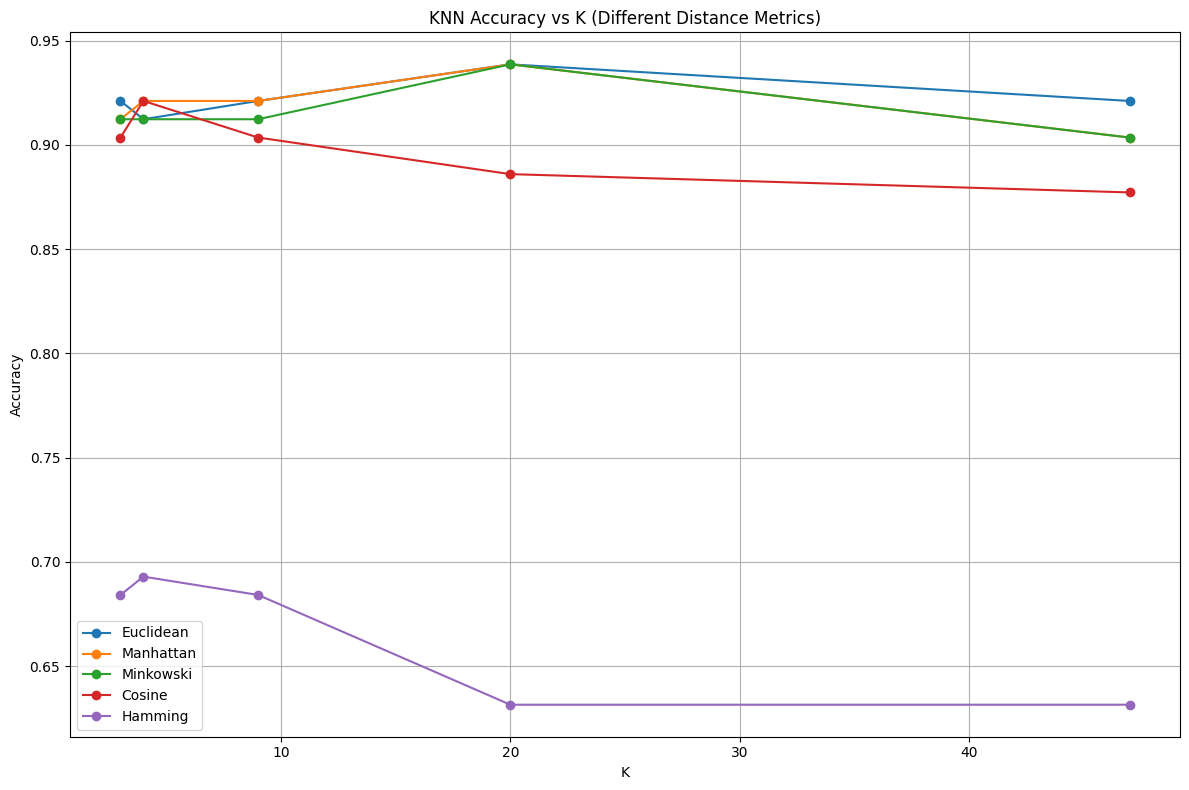

In [9]:
K_values = [3, 4, 9, 20, 47]
results = []

plt.figure(figsize=(12, 8))

for dist_name, dist_func in distance_functions.items():
    acc_list = []
    for k in K_values:
        model = KNNClassifier(k=k, distance_func=dist_func)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        acc_list.append(acc)
        results.append((dist_name, k, acc))
        print(f"[{dist_name}] K={k} → Accuracy={acc:.4f}")
    plt.plot(K_values, acc_list, marker='o', label=dist_name)

plt.title("KNN Accuracy vs K (Different Distance Metrics)")
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## 5. Pick Best Model


In [10]:
best_result = max(results, key=lambda x: x[2])
best_metric, best_k, best_acc = best_result

print("\n=== BEST MODEL RESULTS ===")
print(f"Best Distance Metric : {best_metric}")
print(f"Best K               : {best_k}")
print(f"Best Accuracy        : {best_acc:.4f}")

best_model = KNNClassifier(k=best_k, distance_func=distance_functions[best_metric])
best_model.fit(X_train, y_train)
y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)
precision = precision_score(y_test, y_pred_best)
recall = recall_score(y_test, y_pred_best)

print("\n=== CONFUSION MATRIX ===")
print(cm)
print(f"\nPrecision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")



=== BEST MODEL RESULTS ===
Best Distance Metric : Euclidean
Best K               : 20
Best Accuracy        : 0.9386

=== CONFUSION MATRIX ===
[[72  0]
 [ 7 35]]

Precision: 1.0000
Recall   : 0.8333


## 6. Bonus: Visualize Decision Boundary with PCA


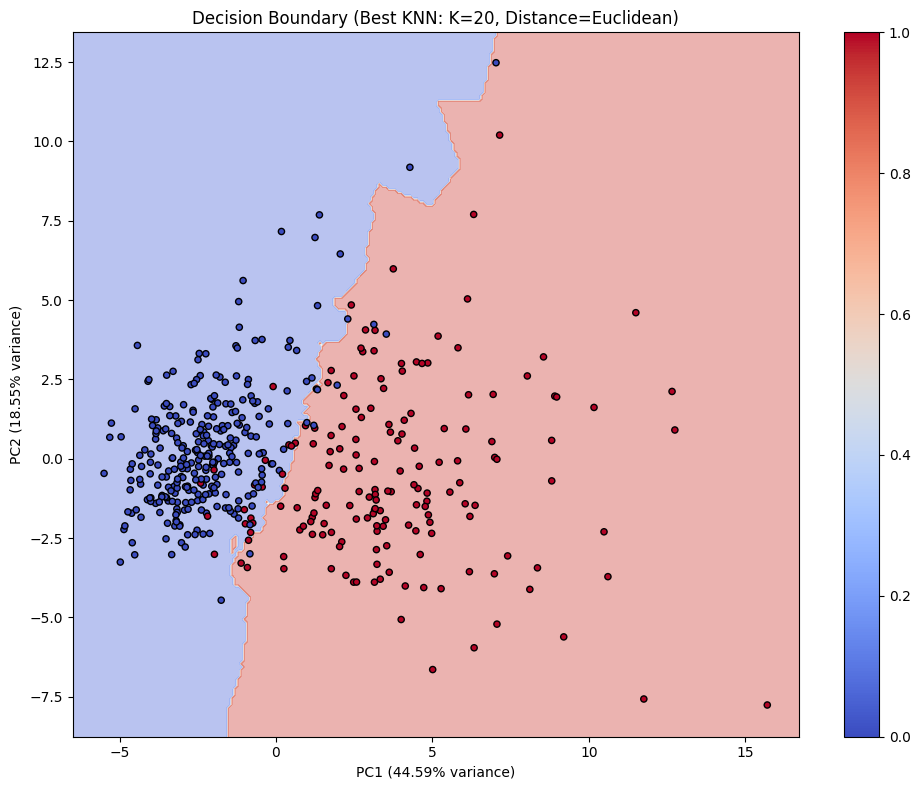


PCA Explained Variance Ratio: [0.44593522 0.18545255]
Total Variance Explained: 63.14%


In [11]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pca = PCA(n_components=2)
X_train_2d = pca.fit_transform(X_train_scaled)
X_test_2d = pca.transform(X_test_scaled)

best_model_2d = KNNClassifier(k=best_k, distance_func=distance_functions[best_metric])
best_model_2d.fit(X_train_2d, y_train)

h = 0.1
x_min, x_max = X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1
y_min, y_max = X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

Z = best_model_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z, alpha=0.4, cmap=plt.cm.coolwarm)
plt.scatter(X_train_2d[:, 0], X_train_2d[:, 1], c=y_train, cmap=plt.cm.coolwarm, s=20, edgecolor="k")
plt.title(f"Decision Boundary (Best KNN: K={best_k}, Distance={best_metric})")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)")
plt.colorbar()
plt.tight_layout()
plt.show()

print(f"\nPCA Explained Variance Ratio: {pca.explained_variance_ratio_}")
print(f"Total Variance Explained: {sum(pca.explained_variance_ratio_):.2%}")
